# Analytical Solution of tau_E and P_loss (IPB98(y,2))

This notebook compares Reactor object solver with "manual" tau_E and P_loss computation


In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import matplotlib.pyplot as plt

# Setup path to fusdb

def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / 'reactors').is_dir() and (path / 'src' / 'fusdb').is_dir():
            return path
    return start

root = find_repo_root(Path.cwd())
src_path = str(root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from fusdb import Reactor
from fusdb.registry import KEV_TO_J
from fusdb.relations.geometry.plasma_geometry import (
    sauter_plasma_cross_sectional_surface,
    sauter_plasma_volume,
    kappa_ipb_from_volume,
)

print(f"Repository root: {root}")


Repository root: /home/alessmor/Scrivania/fusdb


## Reactor configuration
(Be sure to select a reactor compatible with tau_E_IPB98y2 scaling, such as DEMO_2022)


In [2]:
reactor_path = root / "reactors/DEMO_2022/reactor.yaml"

## Method A: Solve in Overwrite Mode

Load the reactor, solve with overwrite mode, and read `tau_E` and `P_loss`.


In [3]:
reactor_solved = Reactor.from_yaml(reactor_path)
reactor_solved.solve(mode="overwrite")

reactor_name = reactor_solved.name or reactor_solved.id or reactor_path.stem

def get_current(reactor, name):
    var = reactor.variables_dict.get(name)
    return None if var is None else var.current_value

P_loss_overwrite = get_current(reactor_solved, "P_loss")
tau_E_overwrite = get_current(reactor_solved, "tau_E")
W_th_overwrite = get_current(reactor_solved, "W_th")

print("Overwrite solution:")
print(f"  P_loss = {P_loss_overwrite/1e6:.2f} MW")
print(f"  tau_E  = {tau_E_overwrite:.4f} s")
print(f"  W_th   = {W_th_overwrite/1e9:.4f} GJ")

Unknown solver tag 'verbosity'. Allowed: ['default_rel_tol', 'lsq', 'max_passes', 'mode', 'n_max', 'solver', 'solving_order']
Inconsistency: relation 'Total fusion power' computed P_fus = 2.24e+09, but input specifies P_fus = 2e+09
Inconsistency: overriding P_fus by 0.0502 -> 2244914780.432935 (global)


Overwrite solution:
  P_loss = 555.85 MW
  tau_E  = 2.2361 s
  W_th   = 1.2429 GJ


## Method B: Step-by-Step (No Solver)

Load the same reactor but avoid calling `solve()`. Instead, retrieve the
inputs and compute the needed quantities explicitly.


In [4]:
reactor_manual = Reactor.from_yaml(reactor_path)


def get_input(reactor, name):
    var = reactor.variables_dict.get(name)
    return None if var is None else var.input_value


def require(name, value):
    if value is None:
        raise ValueError(f"Missing required input '{name}'. Provide it in the YAML or compute it explicitly.")
    return value

# Base inputs
R = require("R", get_input(reactor_manual, "R"))
a = require("a", get_input(reactor_manual, "a"))
A = get_input(reactor_manual, "A") or R / a
I_p = require("I_p", get_input(reactor_manual, "I_p"))
B0 = require("B0", get_input(reactor_manual, "B0"))
H98_y2 = require("H98_y2", get_input(reactor_manual, "H98_y2"))
afuel = require("afuel", get_input(reactor_manual, "afuel"))

# Densities: n_avg and n_la (default n_la = n_avg)
n_avg = get_input(reactor_manual, "n_avg")
f_GW = get_input(reactor_manual, "f_GW")
if n_avg is None and f_GW is not None:
    n_GW = 1e20 * (I_p / 1e6) / (math.pi * a**2)
    n_avg = f_GW * n_GW
n_avg = require("n_avg (or f_GW)", n_avg)

n_la = get_input(reactor_manual, "n_la") or n_avg
n_la = require("n_la", n_la)

# Temperatures: default to T_avg for both electrons and ions
T_avg = get_input(reactor_manual, "T_avg")
T_e = get_input(reactor_manual, "T_e") or T_avg
T_i = get_input(reactor_manual, "T_i") or T_avg
T_e = require("T_e (or T_avg)", T_e)
T_i = require("T_i (or T_avg)", T_i)

# Densities: default to n_avg for both electrons and ions
n_e = get_input(reactor_manual, "n_e") or n_avg
n_i = get_input(reactor_manual, "n_i") or n_avg

# Geometry: V_p and kappa_ipb
V_p = get_input(reactor_manual, "V_p")
kappa_ipb = get_input(reactor_manual, "kappa_ipb")

if V_p is None or kappa_ipb is None:
    kappa = get_input(reactor_manual, "kappa")
    kappa_95 = get_input(reactor_manual, "kappa_95")
    if kappa is None and kappa_95 is not None:
        kappa = 1.12 * kappa_95

    delta = get_input(reactor_manual, "delta")
    delta_95 = get_input(reactor_manual, "delta_95")
    if delta is None and delta_95 is not None:
        delta = 1.5 * delta_95

    squareness = get_input(reactor_manual, "squareness")
    if squareness is None:
        squareness = 0.0

    if V_p is None:
        if kappa is None or delta is None:
            raise ValueError("Need V_p or (kappa/kappa_95 and delta/delta_95) to compute V_p.")
        eps = a / R
        S_phi = float(sauter_plasma_cross_sectional_surface.func(a, kappa, delta, squareness))
        V_p = float(sauter_plasma_volume.func(R, delta, eps, S_phi))

    if kappa_ipb is None:
        kappa_ipb = float(kappa_ipb_from_volume.func(V_p, R, a))

# Thermal stored energy W_th
p_th = (n_e * T_e + n_i * T_i) * KEV_TO_J
W_th_manual = 1.5 * p_th * V_p

print("Manual inputs/derived quantities:")
print(f"  R = {R:.3f} m, a = {a:.3f} m, A = {A:.3f}")
print(f"  I_p = {I_p/1e6:.3f} MA, B0 = {B0:.3f} T")
print(f"  n_la = {n_la/1e19:.3f} x 1e19 m^-3")
print(f"  kappa_ipb = {kappa_ipb:.3f}")
print(f"  W_th = {W_th_manual/1e9:.4f} GJ")


Unknown solver tag 'verbosity'. Allowed: ['default_rel_tol', 'lsq', 'max_passes', 'mode', 'n_max', 'solver', 'solving_order']


Manual inputs/derived quantities:
  R = 9.000 m, a = 2.900 m, A = 3.100
  I_p = 17.750 MA, B0 = 5.860 T
  n_la = 8.062 x 1e19 m^-3
  kappa_ipb = 1.719
  W_th = 1.2429 GJ


## Analytical Solution (cfspopcon-style)

Rearrange the IPB98(y,2) scaling so it is written as:

`tau_E = gamma * P_loss^alpha_P`

Then set `tau_E = W_th / P_loss` and solve for `P_loss`.


In [5]:
alpha_P = -0.69

gamma = (
    H98_y2
    * 0.0562
    * (I_p / 1e6) ** 0.93
    * B0 ** 0.15
    * (n_la / 1e19) ** 0.41
    * R ** 1.97
    * kappa_ipb ** 0.78
    * A ** (-0.58)
    * afuel ** 0.19
    * (1e6) ** 0.69  # convert P_loss from W to MW inside scaling
)

if gamma > 0.0:
    P_loss_manual = (W_th_manual / gamma) ** (1.0 / (1.0 + alpha_P))
else:
    P_loss_manual = np.inf

tau_E_manual = W_th_manual / P_loss_manual

tau_E_scaling = (
    H98_y2
    * 0.0562
    * (I_p / 1e6) ** 0.93
    * B0 ** 0.15
    * (n_la / 1e19) ** 0.41
    * (P_loss_manual / 1e6) ** (-0.69)
    * R ** 1.97
    * kappa_ipb ** 0.78
    * A ** (-0.58)
    * afuel ** 0.19
)

print("Analytical solution:")
print(f"  gamma = {gamma:.6e}")
print(f"  P_loss = {P_loss_manual/1e6:.2f} MW")
print(f"  tau_E (W_th/P_loss) = {tau_E_manual:.4f} s")
print(f"  tau_E (scaling)     = {tau_E_scaling:.4f} s")
print(f"  |difference|        = {abs(tau_E_manual - tau_E_scaling):.2e} s")


Analytical solution:
  gamma = 2.418333e+06
  P_loss = 555.85 MW
  tau_E (W_th/P_loss) = 2.2361 s
  tau_E (scaling)     = 2.2361 s
  |difference|        = 4.44e-16 s


## Comparison


In [6]:
if P_loss_overwrite is not None and tau_E_overwrite is not None:
    print("" + "=" * 70)
    print("COMPARISON: Manual Analytical vs Overwrite Solver")
    print("=" * 70)

    print("P_loss:")
    print(f"  Manual:    {P_loss_manual/1e6:.2f} MW")
    print(f"  Overwrite: {P_loss_overwrite/1e6:.2f} MW")
    print(f"  Difference: {(P_loss_manual - P_loss_overwrite)/1e6:.2f} MW ({100*(P_loss_manual - P_loss_overwrite)/P_loss_overwrite:+.1f}%)")

    print("tau_E:")
    print(f"  Manual:    {tau_E_manual:.4f} s")
    print(f"  Overwrite: {tau_E_overwrite:.4f} s")
    print(f"  Difference: {(tau_E_manual - tau_E_overwrite):.4f} s ({100*(tau_E_manual - tau_E_overwrite)/tau_E_overwrite:+.1f}%)")

    if W_th_overwrite is not None:
        print("W_th:")
        print(f"  Manual:    {W_th_manual/1e9:.4f} GJ")
        print(f"  Overwrite: {W_th_overwrite/1e9:.4f} GJ")
else:
    print("Overwrite values not available for comparison.")


COMPARISON: Manual Analytical vs Overwrite Solver
P_loss:
  Manual:    555.85 MW
  Overwrite: 555.85 MW
  Difference: -0.00 MW (-0.0%)
tau_E:
  Manual:    2.2361 s
  Overwrite: 2.2361 s
  Difference: 0.0000 s (+0.0%)
W_th:
  Manual:    1.2429 GJ
  Overwrite: 1.2429 GJ


## Visualization: tau_E vs P_loss

Plot both relations and show the intersection point.


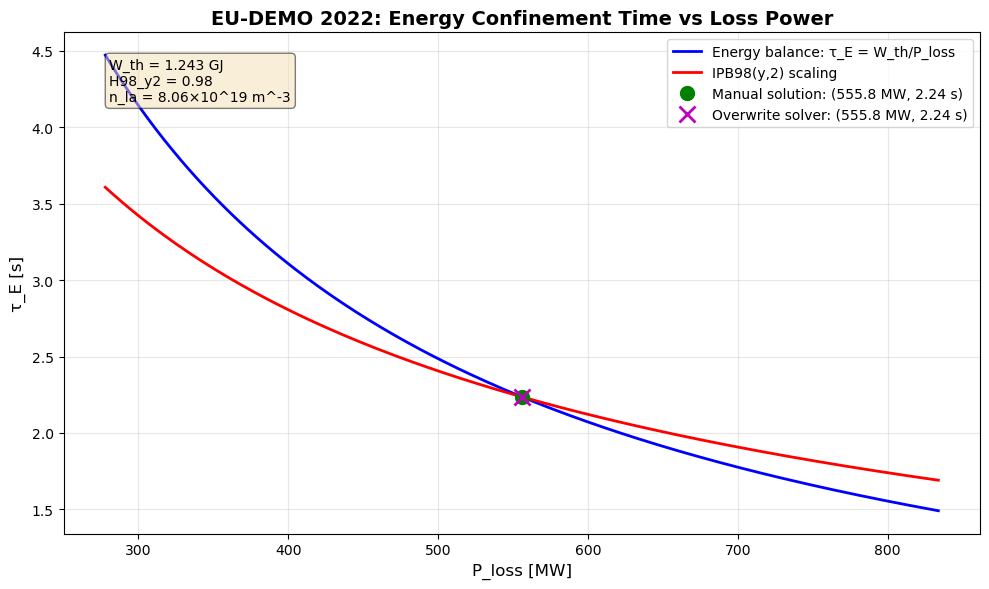

The intersection point is the solution to the coupled system!


In [7]:
if np.isfinite(P_loss_manual):
    P_loss_range = np.linspace(0.5 * P_loss_manual, 1.5 * P_loss_manual, 200)

    tau_E_energy = W_th_manual / P_loss_range
    tau_E_scaling_range = (
        H98_y2
        * 0.0562
        * (I_p / 1e6) ** 0.93
        * B0 ** 0.15
        * (n_la / 1e19) ** 0.41
        * (P_loss_range / 1e6) ** (-0.69)
        * R ** 1.97
        * kappa_ipb ** 0.78
        * A ** (-0.58)
        * afuel ** 0.19
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(P_loss_range / 1e6, tau_E_energy, "b-", linewidth=2, label="Energy balance: τ_E = W_th/P_loss")
    ax.plot(P_loss_range / 1e6, tau_E_scaling_range, "r-", linewidth=2, label="IPB98(y,2) scaling")
    ax.plot(P_loss_manual / 1e6, tau_E_manual, "go", markersize=10,
            label=f"Manual solution: ({P_loss_manual/1e6:.1f} MW, {tau_E_manual:.2f} s)", zorder=5)

    if P_loss_overwrite is not None and tau_E_overwrite is not None:
        ax.plot(P_loss_overwrite / 1e6, tau_E_overwrite, "mx", markersize=12, markeredgewidth=2,
                label=f"Overwrite solver: ({P_loss_overwrite/1e6:.1f} MW, {tau_E_overwrite:.2f} s)", zorder=5)

    ax.set_xlabel("P_loss [MW]", fontsize=12)
    ax.set_ylabel("τ_E [s]", fontsize=12)
    ax.set_title(f"{reactor_name}: Energy Confinement Time vs Loss Power", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    textstr = f"W_th = {W_th_manual/1e9:.3f} GJ\nH98_y2 = {H98_y2:.2f}\nn_la = {n_la/1e19:.2f}×10^19 m^-3"

    props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment="top", bbox=props)

    plt.tight_layout()
    plt.show()

    print("The intersection point is the solution to the coupled system!")
else:
    print("P_loss_manual is not finite; skipping plot.")
